# Task 1: Data Preprocessing and Exploratory Data Analysis (EDA)

**Objective:**  
Prepare and analyze historical price data for TSLA, BND, and SPY (Jan 2015 – Jan 2026) to understand trends, volatility, and correlations.  
This analysis supports portfolio management by providing clean datasets, risk metrics, and initial visual insights.

**Scope:**  
1. Data extraction from YFinance  
2. Data cleaning and alignment  
3. Exploratory visualizations  
4. Stationarity testing using ADF  
5. Risk metrics (VaR, Sharpe Ratio, Drawdown)  
6. Bonus: Aligned dataset for consistent forecasting


In [158]:
import pandas as pd
import numpy as np
import os
import time
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.stats import norm
from statsmodels.tsa.stattools import adfuller

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# Project directories
project_root = ".."

raw_folder = os.path.join(project_root, "data", "raw")
processed_folder = os.path.join(project_root, "data", "processed")
figures_folder = os.path.join(project_root, "reports", "figures")

for folder in [raw_folder, processed_folder, figures_folder]:
    os.makedirs(folder, exist_ok=True)

# Asset universe & date range
tickers = ["TSLA", "BND", "SPY"]
start_date = "2015-01-01"
end_date = "2026-01-16"


### Data Extraction

We download historical daily prices for each ticker using the `yfinance` library.  
We include retry logic to handle API/network errors.


In [159]:
data_dict = {}

for ticker in tickers:
    print(f"Downloading {ticker}...")
    for attempt in range(1, 4):
        try:
            df = yf.download(
                ticker,
                start=start_date,
                end=end_date,
                progress=False,
                timeout=30
            )

            if df.empty:
                time.sleep(3)
                continue

            series = df["Adj Close"] if "Adj Close" in df.columns else df["Close"]
            series.name = ticker
            data_dict[ticker] = series
            break

        except Exception as e:
            print(f"Retry {attempt} failed for {ticker}: {e}")
            time.sleep(3)

# Combine & align
prices = pd.concat(data_dict.values(), axis=1)
prices.columns = data_dict.keys()
prices = prices.ffill()

# Save cleaned prices
prices.to_csv(os.path.join(processed_folder, "cleaned_prices.csv"))
prices.head()


,TSLA,BND,SPY
Date,,,
2015-01-02,14.620667,60.385941,170.589615
2015-01-05,14.006000,60.561295,167.508804
2015-01-06,14.085333,60.736652,165.931107
2015-01-07,14.063333,60.773228,167.998825
2015-01-08,14.041333,60.678246,170.979874


Interpretation

Forward-filling handles missing trading days

Alignment ensures consistent timestamps across assets

This is critical for correlation and forecasting

In [160]:
print("Data shape:", prices.shape)
print("\nMissing values:\n", prices.isna().sum())

prices = prices.ffill().bfill()

Data shape: (2776, 3)

Missing values:
 TSLA    0
BND     0
SPY     0
dtype: int64


Why no scaling?
Price levels differ significantly across assets, but returns, correlations, volatility, VaR, and Sharpe ratios are scale-independent, so normalization is unnecessary for this analysis.

#  Step 2: Compute Daily Returns
- Calculate daily percentage change for each asset
- Save aligned returns to `data/processed/returns.csv`   
Daily returns are computed as percentage changes between consecutive days.  
These will be used for risk metrics, stationarity testing, and correlation analysis.



In [161]:

# daily returns
returns = prices.pct_change().dropna()

# Save 
returns.to_csv(os.path.join(processed_folder, "returns_aligned.csv"))
returns.head()


,TSLA,BND,SPY
Date,,,
2015-01-05,-0.042041,0.002904,-0.018060
2015-01-06,0.005664,0.002896,-0.009419
2015-01-07,-0.001562,0.000602,0.012461
2015-01-08,-0.001564,-0.001563,0.017744
2015-01-09,-0.018802,0.001685,-0.008014


Why Returns?

Returns are stationary (required for ARIMA/LSTM)

Used for risk, correlation, and performance metrics

## Step 3: Exploratory Data Analysis (EDA)

We visualize the following:
1. Price series over time
2. Daily returns
3. Correlation heatmap
4. Portfolio cumulative growth

 - Plot price series over time
 - Plot correlation heatmap of returns
 - Figures saved to `reports/figures`

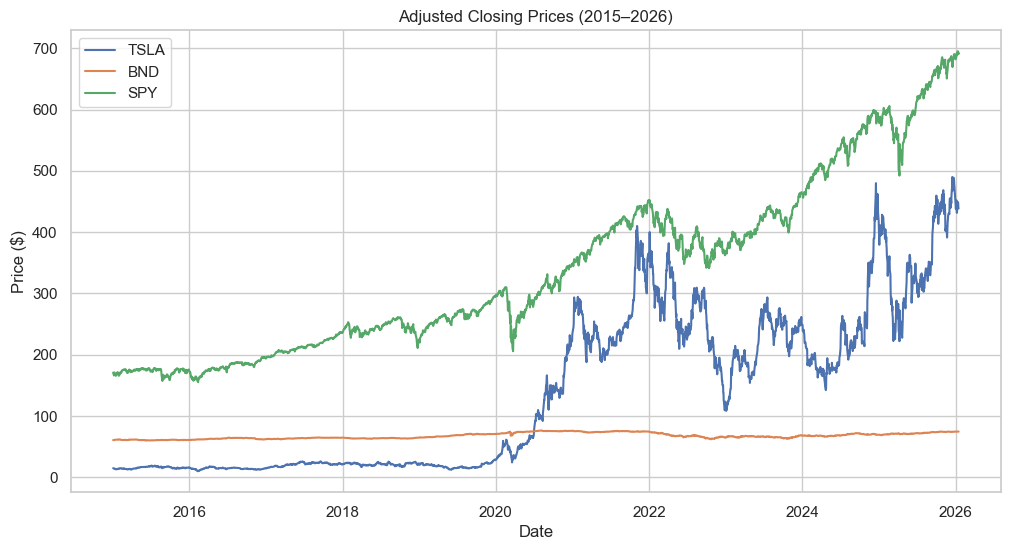

In [162]:
# 📈 Price Series 
plt.figure(figsize=(12,6))
for ticker in tickers:
    plt.plot(prices[ticker], label=ticker)
plt.title("Adjusted Closing Prices (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.savefig(os.path.join(figures_folder, "price_series.png"), dpi=300)
plt.show()


Insight

TSLA shows high growth and volatility

BND is stable (low risk)

SPY reflects long-term market trend

📉 Daily Returns

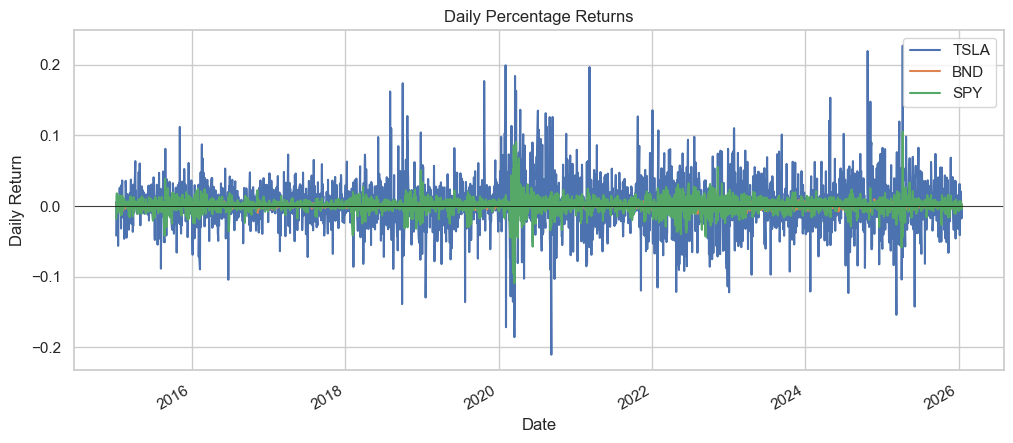

In [163]:
#  Daily returns
returns.plot(title="Daily Percentage Returns")
plt.axhline(0, color="black", linewidth=0.5)
plt.ylabel("Daily Return")
plt.savefig(os.path.join(figures_folder, "daily_returns.png"), dpi=300)
plt.show()


Insight

TSLA exhibits extreme volatility

BND returns cluster tightly around zero

SPY lies between both extremes

🔗 Correlation Heatmap

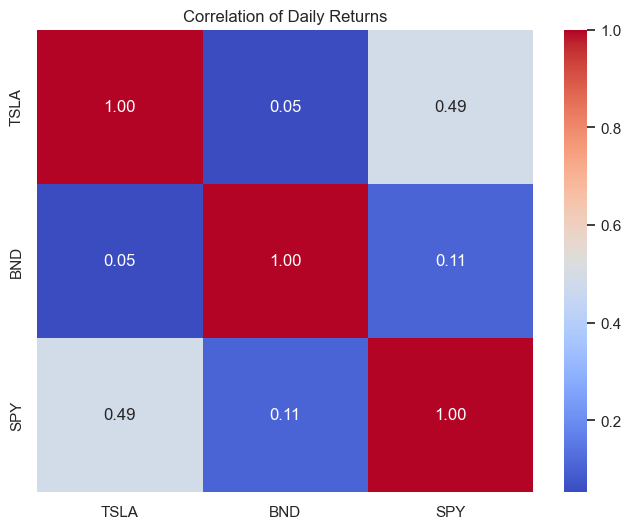

In [164]:
# %%
plt.figure(figsize=(8,6))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of Daily Returns")
plt.savefig(os.path.join(figures_folder, "correlation_heatmap.png"), dpi=300)
plt.show()


Interpretation

TSLA–SPY: moderate correlation (~0.49)

BND: weak correlation → diversification benefit

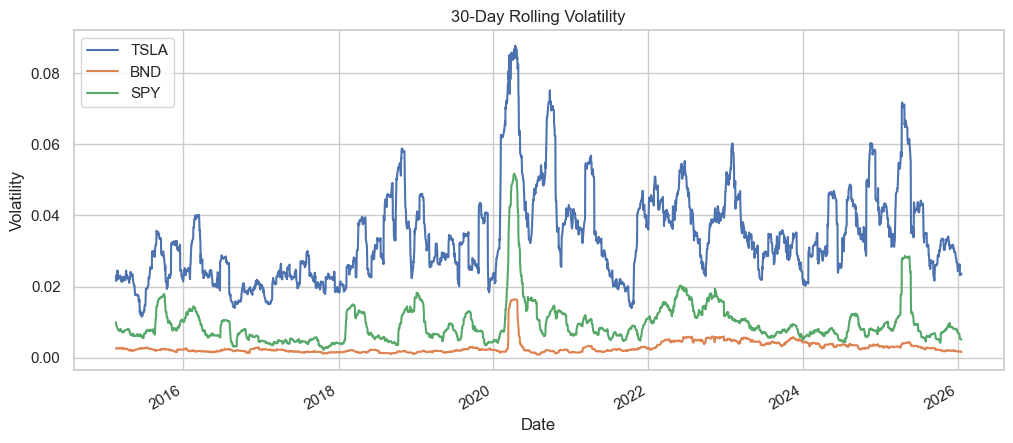

In [165]:
# Cell 8: Rolling mean and volatility
rolling_mean = prices.rolling(window=30).mean()
rolling_vol = returns.rolling(window=30).std()

rolling_vol.plot(title="30-Day Rolling Volatility")
plt.ylabel("Volatility")
plt.savefig(os.path.join(figures_folder, "rolling_volatility.png"), dpi=300)
plt.show()


## Step 4: Outlier Detection (Extreme Returns)

We identify unusually large price movements using a ±5% daily return threshold.

In [166]:
# Cell 9: Outlier detection
threshold = 0.05
outliers = returns[(returns.abs() > threshold)]

for ticker in tickers:
    print(f"\n{ticker} extreme return days:")
    print(outliers[ticker].dropna().head())



TSLA extreme return days:
Date
2015-01-14   -0.056597
2015-04-06    0.063351
2015-04-27    0.060065
2015-07-21   -0.054879
2015-08-06   -0.088846
Name: TSLA, dtype: float64

BND extreme return days:
Date
2020-03-12   -0.054385
Name: BND, dtype: float64

SPY extreme return days:
Date
2018-12-26    0.050525
2020-03-09   -0.078095
2020-03-10    0.051745
2020-03-12   -0.095677
2020-03-13    0.085486
Name: SPY, dtype: float64


Interpretation:
TSLA shows frequent extreme movements, confirming its high-risk nature, while BND remains stable with very few outliers.

## Step 5: Stationarity Testing (ADF Test)

We perform Augmented Dickey-Fuller (ADF) tests on both prices and returns.  
This helps determine whether series are stationary, which is crucial for ARIMA modeling.


In [167]:
def adf_test(series, name):
    result = adfuller(series)
    print(f"{name} | ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}")
    if result[1] < 0.05:
        print("→ Stationary ✅\n")
    else:
        print("→ Non-stationary ❌\n")

for col in prices.columns:
    adf_test(prices[col], f"{col} Prices")
    adf_test(returns[col], f"{col} Returns")


TSLA Prices | ADF Statistic: -0.7832, p-value: 0.8240
→ Non-stationary ❌

TSLA Returns | ADF Statistic: -53.0309, p-value: 0.0000
→ Stationary ✅

BND Prices | ADF Statistic: -1.0645, p-value: 0.7290
→ Non-stationary ❌

BND Returns | ADF Statistic: -10.4396, p-value: 0.0000
→ Stationary ✅

SPY Prices | ADF Statistic: 1.1907, p-value: 0.9959
→ Non-stationary ❌

SPY Returns | ADF Statistic: -17.2313, p-value: 0.0000
→ Stationary ✅



Result Summary:

Price series are non-stationary

Daily returns are stationary

Confirms returns are suitable for forecasting models

# ## Step 6: Risk Metrics

We calculate:
- Annualized volatility
- Annualized return
- Sharpe ratio (risk-adjusted return)
- 5% Value at Risk (VaR)
- Maximum drawdown
- Portfolio metrics with example weights: `[0.3, 0.5, 0.2]`
- Save metrics to `data/processed/risk_metrics.csv`



In [168]:

# Annualized volatility per asset
volatility = returns.std() * np.sqrt(252)
print("Annualized Volatility (per asset):\n", volatility)

# Value at Risk (5%) per asset
confidence_level = 0.05
VaR = returns.quantile(confidence_level)
print("\n5% Value at Risk (VaR) (per asset):\n", VaR)

# Maximum drawdown (optional bonus)
def max_drawdown(series):
    cumulative = (1 + series).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    return drawdown.min()

drawdowns = returns.apply(max_drawdown)
print("\nMaximum Drawdowns (optional bonus):\n", drawdowns)


Annualized Volatility (per asset):
 TSLA    0.576820
BND     0.053560
SPY     0.177645
dtype: float64

5% Value at Risk (VaR) (per asset):
 TSLA   -0.052528
BND    -0.004796
SPY    -0.016716
Name: 0.05, dtype: float64

Maximum Drawdowns (optional bonus):
 TSLA   -0.736322
BND    -0.185821
SPY    -0.337173
dtype: float64



Portfolio Metrics (optional bonus):
Annual Return: 0.1811
Annual Volatility: 0.1966
Sharpe Ratio: 0.8197


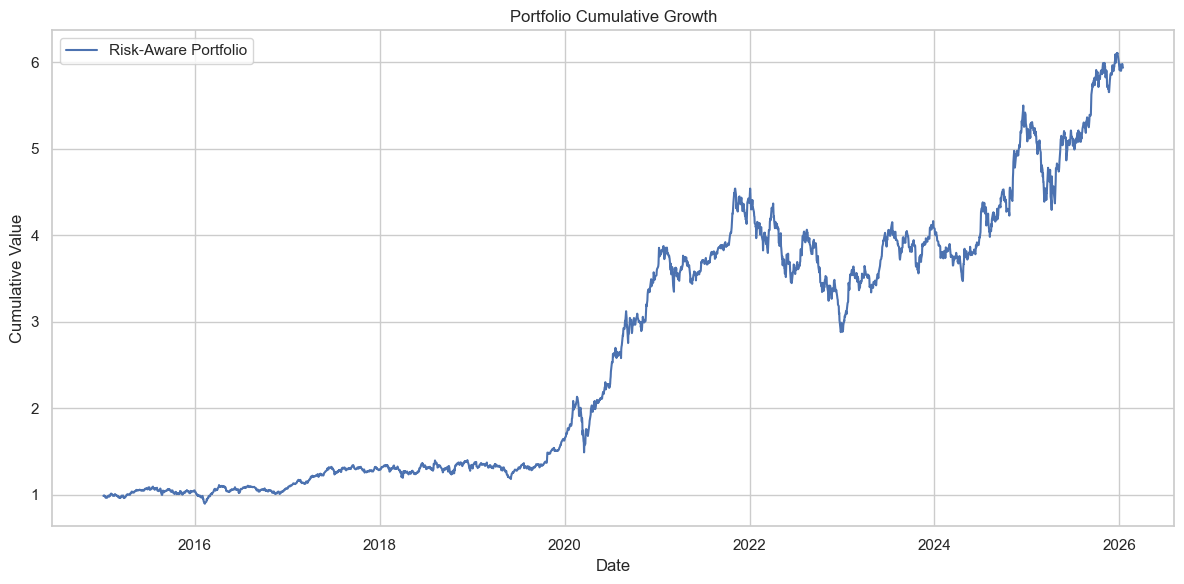

In [169]:
# Portfolio Example (optional)
weights = np.array([0.3, 0.5, 0.2])
portfolio_returns = returns.dot(weights)

annual_return = portfolio_returns.mean() * 252
annual_volatility = portfolio_returns.std() * np.sqrt(252)
risk_free_rate = 0.02
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

print("\nPortfolio Metrics (optional bonus):")
print("Annual Return:", round(annual_return, 4))
print("Annual Volatility:", round(annual_volatility, 4))
print("Sharpe Ratio:", round(sharpe_ratio, 4))

# Portfolio cumulative growth plot
plt.figure(figsize=(12,6))
plt.plot((1 + portfolio_returns).cumprod(), label="Risk-Aware Portfolio")
plt.title("Portfolio Cumulative Growth")
plt.xlabel("Date")
plt.ylabel("Cumulative Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(figures_folder, "portfolio_growth.png"), dpi=300)
plt.show()



In [170]:
## Step 7: Bonus – Aligned Data & Visualizations
 


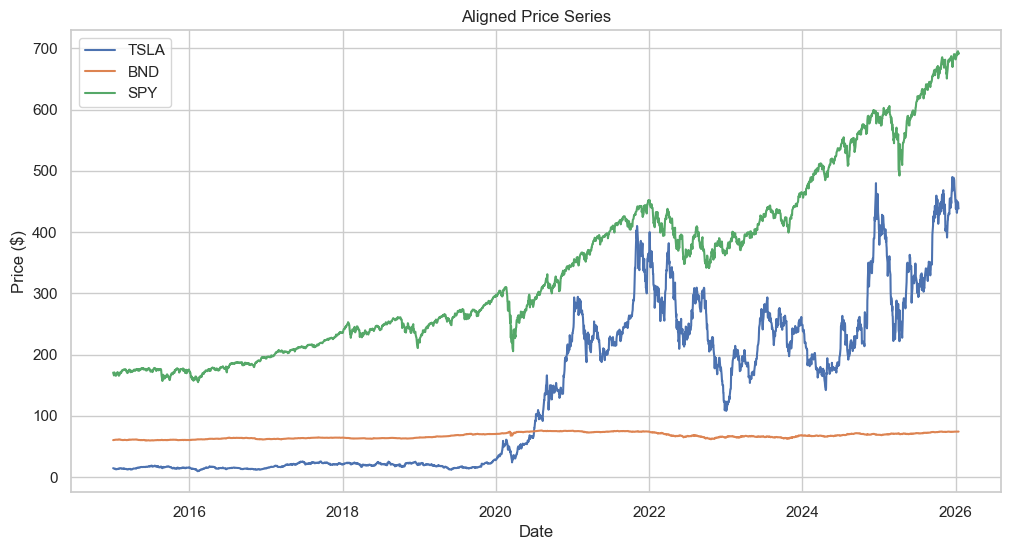

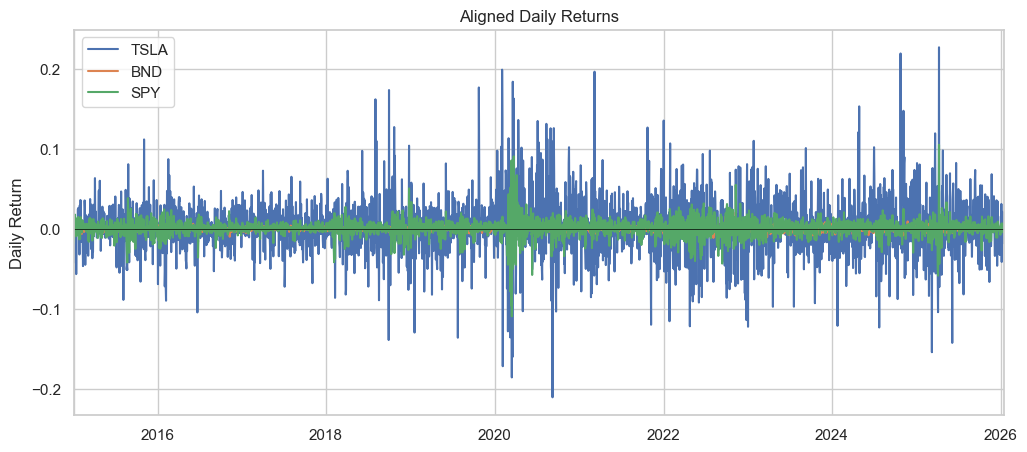

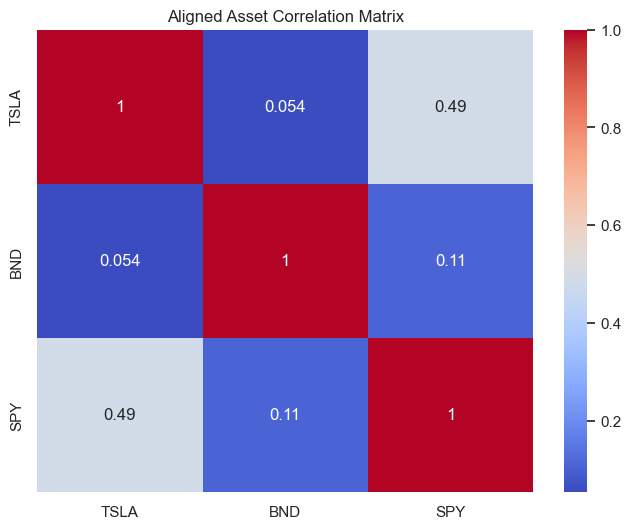

In [171]:
# %%
# Align full business day index
full_index = pd.date_range(start=prices.index.min(), end=prices.index.max(), freq='B')
aligned_prices = prices.reindex(full_index).ffill()
aligned_returns = aligned_prices.pct_change().dropna()

# Save aligned CSVs
aligned_prices.to_csv(os.path.join(processed_folder, "prices_aligned.csv"))
aligned_returns.to_csv(os.path.join(processed_folder, "returns_aligned.csv"))

# Bonus plots
plt.figure(figsize=(12,6))
for ticker in tickers:
    plt.plot(aligned_prices[ticker], label=ticker)
plt.title("Aligned Price Series")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.savefig(os.path.join(figures_folder, "aligned_price_series.png"), dpi=300)
plt.show()

aligned_returns.plot(title="Aligned Daily Returns")
plt.axhline(0, color="black", linewidth=0.5)
plt.ylabel("Daily Return")
plt.savefig(os.path.join(figures_folder, "aligned_daily_returns.png"), dpi=300)
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(aligned_returns.corr(), annot=True, cmap="coolwarm")
plt.title("Aligned Asset Correlation Matrix")
plt.savefig(os.path.join(figures_folder, "aligned_correlation_heatmap.png"), dpi=300)
plt.show()


# ✅ PROJECT OUTPUTS SUMMARY

In [172]:
# %%
print("\n✅ PROJECT OUTPUTS SUMMARY\n")

csv_files = glob.glob(os.path.join(processed_folder, "*.csv"))
print("Saved CSV files:")
for f in csv_files:
    print(" -", os.path.basename(f))

figure_files = glob.glob(os.path.join(figures_folder, "*.png"))
print("\nSaved Figures:")
for f in figure_files:
    print(" -", os.path.basename(f))




✅ PROJECT OUTPUTS SUMMARY

Saved CSV files:
 - cleaned_prices.csv
 - prices_aligned.csv
 - returns.csv
 - returns_aligned.csv
 - risk_metrics.csv

Saved Figures:
 - aligned_correlation_heatmap.png
 - aligned_daily_returns.png
 - aligned_price_series.png
 - arima_forecast.png
 - correlation_heatmap.png
 - daily_returns.png
 - lstm_forecast.png
 - portfolio_growth.png
 - price_series.png
 - rolling_volatility.png
 - tsla_prices.png
